## 1. Import Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 120, "font.family": "sans-serif", "axes.spines.top": False, "axes.spines.right": False})
print("All libraries loaded.")

All libraries loaded.


## 2. Load and Inspect the Dataset

In [13]:
raw_data, meta = arff.loadarff("dataset_31_credit-g.arff")
df = pd.DataFrame(raw_data)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.decode("utf-8")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: 1000 rows x 21 columns
Missing values: 0


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [14]:
print(df.dtypes)

checking_status               str
duration                  float64
credit_history                str
purpose                       str
credit_amount             float64
savings_status                str
employment                    str
installment_commitment    float64
personal_status               str
other_parties                 str
residence_since           float64
property_magnitude            str
age                       float64
other_payment_plans           str
housing                       str
existing_credits          float64
job                           str
num_dependents            float64
own_telephone                 str
foreign_worker                str
class                         str
dtype: object


Class distribution:
class
good    700
bad     300
Name: count, dtype: int64


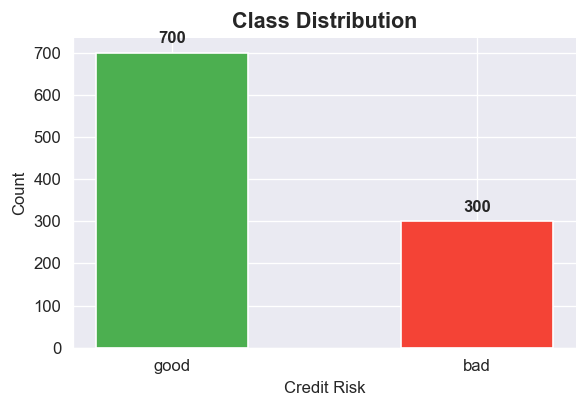

In [15]:
print("Class distribution:")
print(df["class"].value_counts())

fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df["class"].value_counts()
bars = ax.bar(counts.index, counts.values, color=["#4CAF50", "#F44336"], edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%d", padding=4, fontweight="bold")
ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Credit Risk")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Preprocessing - Encode Categorical Features

In [16]:
df_encoded = df.copy()
label_encoders = {}
categorical_cols = df_encoded.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print(f"Encoded {len(categorical_cols)} categorical columns:")
print(categorical_cols)
df_encoded.head()

Encoded 14 categorical columns:
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker', 'class']


/var/folders/h9/1n1cwynx4s5dp9lkywdmlcyc0000gn/T/ipykernel_17219/996061950.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_encoded.select_dtypes(include="object").columns.tolist()


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,1,6.0,1,6,1169.0,4,3,4.0,3,2,...,3,67.0,1,1,2.0,1,1.0,1,1,1
1,0,48.0,3,6,5951.0,2,0,2.0,0,2,...,3,22.0,1,1,1.0,1,1.0,0,1,0
2,3,12.0,1,2,2096.0,2,1,2.0,3,2,...,3,49.0,1,1,1.0,3,2.0,0,1,1
3,1,42.0,3,3,7882.0,2,1,2.0,3,1,...,1,45.0,1,0,1.0,1,2.0,0,1,1
4,1,24.0,2,4,4870.0,2,0,3.0,3,2,...,2,53.0,1,0,2.0,1,2.0,0,1,0


## 4. Train / Test Split

In [17]:
X = df_encoded.drop(columns=["class"])
y = df_encoded["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 700
Testing  samples : 300
Features         : 20


## 5. Train the Random Forest

In [18]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest trained.")
print(f"  Trees         : {rf.n_estimators}")
print(f"  Features used : {rf.n_features_in_}")

Random Forest trained.
  Trees         : 200
  Features used : 20


## 6. Evaluate Performance

In [19]:
y_pred = rf.predict(X_test)

le_class = label_encoders["class"]
target_names = le_class.classes_

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy : 0.7300  (73.00%)

Classification Report:
              precision    recall  f1-score   support

         bad       0.57      0.41      0.48        90
        good       0.77      0.87      0.82       210

    accuracy                           0.73       300
   macro avg       0.67      0.64      0.65       300
weighted avg       0.71      0.73      0.72       300



## 7. Confusion Matrix

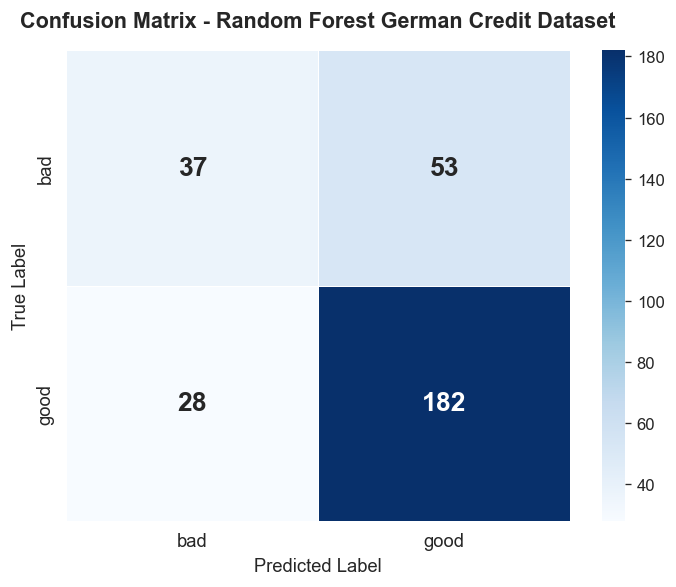

True  Negatives (bad  -> bad)  : 37
False Positives (bad  -> good) : 53
False Negatives (good -> bad)  : 28
True  Positives (good -> good) : 182


In [20]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, linecolor="white",
    xticklabels=target_names, yticklabels=target_names,
    ax=ax, annot_kws={"size": 16, "weight": "bold"}
)
ax.set_title("Confusion Matrix - Random Forest German Credit Dataset", fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives (bad  -> bad)  : {tn}")
print(f"False Positives (bad  -> good) : {fp}")
print(f"False Negatives (good -> bad)  : {fn}")
print(f"True  Positives (good -> good) : {tp}")